# ДЗ 4. Задание 5

In [2]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [43]:
records = SeqIO.parse("chr1.fna", "fasta")
record = next(records)
sequence_all = record.seq
sequence = sequence_all[10000:20000]

## Частоты

In [44]:
nucleotides = ['A', 'C', 'G', 'T']
counts = {i+j: 0 for i in nucleotides for j in nucleotides}

for i in range(len(sequence)-1):
    pair = sequence[i:i+2]
    if pair in counts:
        counts[pair] += 1

In [45]:
counts

{'AA': 323,
 'AC': 399,
 'AG': 705,
 'AT': 257,
 'CA': 678,
 'CC': 852,
 'CG': 232,
 'CT': 742,
 'GA': 499,
 'GC': 729,
 'GG': 854,
 'GT': 433,
 'TA': 185,
 'TC': 516,
 'TG': 728,
 'TT': 342}

## Матрица переходов

In [25]:
count_matrix = np.zeros((4, 4))

for i, n in enumerate(nucleotides):
    for j, m in enumerate(nucleotides):
        count_matrix[i, j] = counts[n + m]

In [27]:
P = count_matrix / count_matrix.sum(axis=1, keepdims=True)

df_P = pd.DataFrame(P, index=nucleotides, columns=nucleotides)
df_P

,A,C,G,T
A,0.191805,0.236936,0.418646,0.152613
C,0.270767,0.340256,0.092652,0.296326
G,0.198410,0.289861,0.339563,0.172167
T,0.104461,0.291361,0.411067,0.193111


Проверим сумму строк

In [29]:
for i, n in enumerate(nucleotides):
    print(f"{n}: {P[i].sum():.10f}")

A: 1.0000000000
C: 1.0000000000
G: 1.0000000000
T: 1.0000000000


## Стационарное распределение

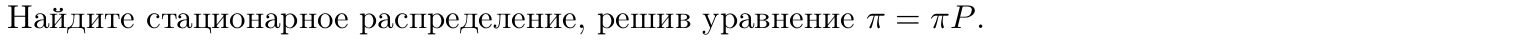

что-то вроде равновестия - распределение сейчас = новое распределение 

In [31]:
A = (P.T - np.eye(4))
A[-1] = 1.0
b = np.zeros(4)
b[-1] = 1.0
pi = np.linalg.solve(A, b)

print("Стационарное распределение pi")
for i, n in enumerate(nucleotides):
    print(f"  pi({n}) = {pi[i]:.6f}")
print(f"  Сумма = {pi.sum():.4f}")

Стационарное распределение pi
  pi(A) = 0.198749
  pi(C) = 0.294497
  pi(G) = 0.297527
  pi(T) = 0.209227
  Сумма = 1.0000


## Реальные частоты

In [32]:
total=0
for n in nucleotides:
    total += sequence.count(n)
observed = {}
for n in nucleotides:
    observed[n] = sequence.count(n) / total

In [34]:
for n in nucleotides:
    print(f"f({n}) = {observed[n]:.6f}")

f(A) = 0.198731
f(C) = 0.295099
f(G) = 0.296862
f(T) = 0.209308


In [37]:
df = pd.DataFrame({
    'Нуклеотид': nucleotides,
    'стационарная модель': pi,
    'наблюдаемое': [observed[n] for n in nucleotides]
})
df

,Нуклеотид,стационарная модель,наблюдаемое
0,A,0.198749,0.198731
1,C,0.294497,0.295099
2,G,0.297527,0.296862
3,T,0.209227,0.209308


Найденные pi нуклеотидов из модели стационарного распределения близки к реально наблюдаемым частотам в ДНК, так что модель работает хорошо